In [2]:
hbarc = 197.327053                    #(* [MeV fm] *)
MN0 = (938.27231 + 939.56563)/2       #(* average nucleon mass [MeV] *)
MN  = MN0/hbarc**2			          #(* average nucleon mass in units [1/(MeV fm^2)] *)

print("MN is:",MN)

MN is: 0.02411320030742015


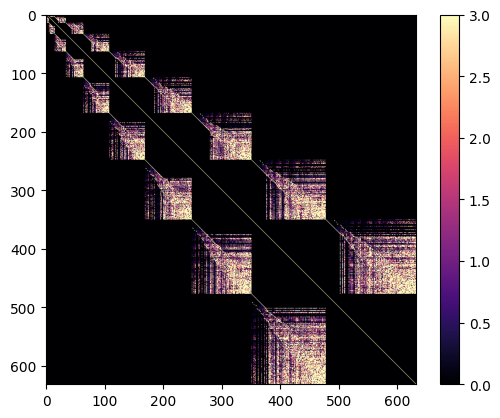

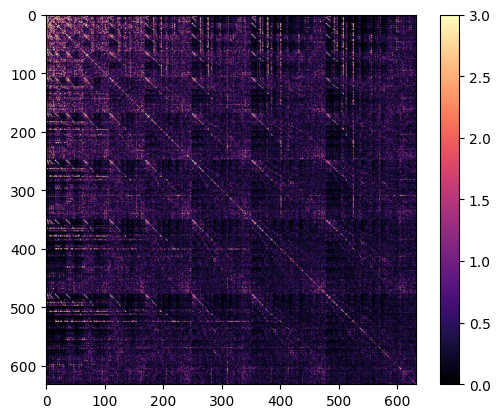

Symmetric? True


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Wolfram "SunsetColors" equivalent: use a similar colormap

#sunset_cmap = plt.get_cmap("magma")

# ArrayPlot / DensityPlot / ListDensityPlot:
# Use cmap=sunset_cmap when creating the plots, e.g.:
# plt.imshow(data, cmap=sunset_cmap)
# plt.contourf(X, Y, Z, cmap=sunset_cmap)

# ListLinePlot:
# Plot markers automatically, with a frame and no visible axes

#plt.plot(x, y, marker='o')
#plt.box(True)
#plt.axis('off')
#plt.gca().set_aspect(0.8)

#Important: unlike Wolfram's SetOptions, these settings are not automatically applied to every future Matplotlib plot. You generally specify them when creating each plot.

TMat = np.loadtxt("kinetic_EMax20_hw20.dat")
VMat = np.loadtxt("chi2b3b_EMax20_hw20.dat")
HMat = TMat + VMat

# display TMat and VMat
plt.imshow(np.abs(TMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()
plt.imshow(np.abs(VMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

# basic checks
print("Symmetric?", np.allclose(HMat, HMat.T))

In [4]:
def commutator(A, B):
    """Return [A, B] = AB - BA."""
    return A @ B - B @ A

EtaMat = commutator(TMat, HMat)

print("Antisymmetric?", np.allclose(EtaMat, -EtaMat.T))

Antisymmetric? True


In [ ]:
def wegner_generator(H, T):
    """Wegner generator eta = [T, H]."""
    return commutator(T, H)

def srg_rhs(a, H):
    """Right-hand side of dH/da = MN^2 * [eta, H]"""
    eta = wegner_generator(H, TMat)
    dHda = MN**2 * commutator(eta, H)
    return dHda

# Create an empty SRG evolution storage, with first element VMat (initial value)
VMatSRG = {} 
VMatSRG[0.0] = VMat

a0 = 0.0       #initial value
aDel = 0.0001 #integration step
nSteps = 500  # takes one minute with 500

def euler_integration(a):
    aGrid = np.linspace(a, a + aDel * nSteps, nSteps + 1)
    HMat = TMat + VMatSRG[a]
    for a in aGrid:
        HMatDel = aDel * srg_rhs(a,HMat)
        HMat = HMat + HMatDel
    a = np.round(a, 5)
    VMatSRG[a] = HMat - TMat

for i in range(0,3):
    euler_integration(a0 + 0.05 * i)

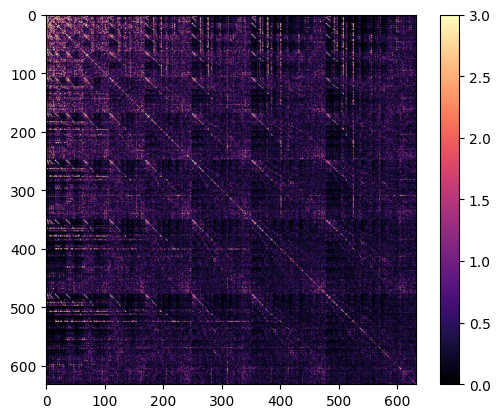

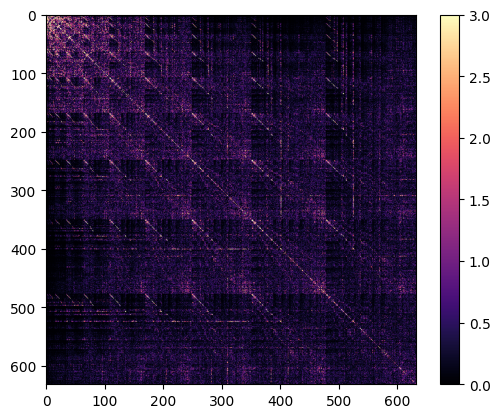

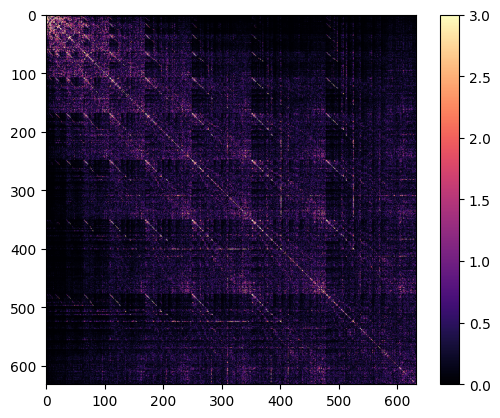

In [6]:
plt.imshow(np.abs(VMatSRG[0.0]), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

plt.imshow(np.abs(VMatSRG[0.05]), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

plt.imshow(np.abs(VMatSRG[0.1]), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

In [7]:
for a in np.arange(0.0, 0.15, 0.05):
    HMat = TMat + VMatSRG[a]

    eigenvalues = np.linalg.eigvalsh(HMat)
    fiveLowestMagnitude = eigenvalues[np.argsort(np.abs(eigenvalues))[:5]]

    result = np.min(fiveLowestMagnitude)

    print(f"The eigenvalue corresponding to a = {a} is: {result}")

The eigenvalue corresponding to a = 0.0 is: -8.07045774855503
The eigenvalue corresponding to a = 0.05 is: -8.088927343902375
The eigenvalue corresponding to a = 0.1 is: -8.089783300945685


lowest magnitude eigenvalue is changing very slowly with a. That shouldn't happen however we recall we are integrating with Euler's method, so numerical errors can get big.


for a = 0.0
[[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
for a = 0.05
[[2, np.float64(-4.739193420637807)], [4, np.float64(-6.607541022913544)], [6, np.float64(-7.50120838168773)], [8, np.float64(-7.7905242724582555)], [10, np.float64(-7.987092052158848)], [12, np.float64(-8.028682106823263)], [14, np.float64(-8.050914456816203)], [16, np.float64(-8.059786750627822)], [18, np.float64(-8.065658343683916)], [20, np.float64(-8.088927343902375)]]
for a = 0.1
[[2, np.float64(-6.1478137046060315)], [4, np.float64(-7.383375241512019)], [6, np.float64(-7.86212588252253)], [8, np.float64(-7.965671622924473)], [10, np.float64(-8.027679091380959)], [12, np.float64(-8.05

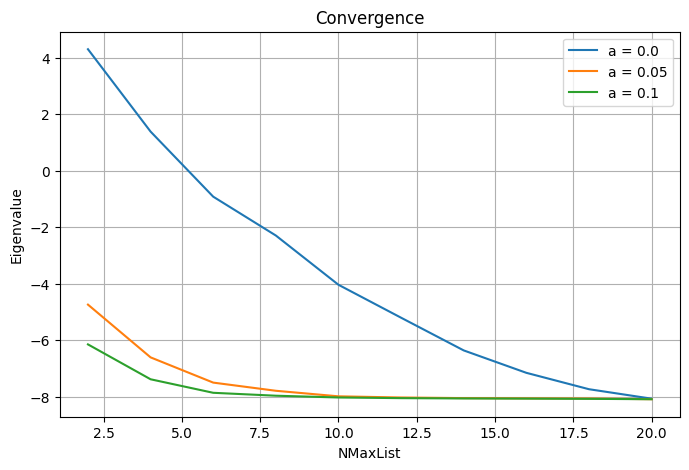

In [20]:
#rows, cols = HMat.shape

#print(HMat.shape)
#print(f"Rows: {rows}, Columns: {cols}")

NMaxList = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] #number of states corresponding to the submatrices below
DimList = [5, 15, 34, 64, 108, 169, 249, 351, 478, 632] #size of the submatrices
EEList = {}

for a in np.arange(0.0, 0.15, 0.05):
    print(f"for a = {a}")
    EEList[a] = []
    for i in range(len(NMaxList)):
        HMat = TMat+VMatSRG[a]
        subHMat = HMat[:DimList[i], :DimList[i]]
        eigenvalues = np.linalg.eigvalsh(subHMat) 
        EE0 = eigenvalues[0] # eigenvalues is in ascending order allegedly
        EEList[a].append([NMaxList[i], EE0])
    print(EEList[a])

plt.figure(figsize=(8, 5))
for a in np.arange(0.0, 0.15, 0.05):
    x, y = zip(*EEList[a])
    plt.plot(x,y, label=f"a = {a}")
plt.xlabel("NMaxList")
plt.ylabel("Eigenvalue")
plt.title("Convergence")
plt.legend()
plt.grid(True)
plt.show()
